Title: capacity_data_offshore_yearly.ipynb

Purpose: Transform the xml capacity data into some gridded format for each year separately 

Author: Onno Nennecke on 16.12.2025 Modified: 16.12.2025

Input data: 

- Wind energy units from the MaStR
    - This file lies here: /climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml

Output data:

- wind_offshore_ic_{year}.nc and wind_offnshore_height_weighted_{year}.nc
    - This file lies here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data


In [1]:
import pandas as pd
import geopandas as gpd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


import Functions.grid_func as grid_func # Own function to create 1x1 degree grid

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
# Load the XML file
tree = ET.parse('/climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml')
root = tree.getroot()


Felder relevant:
columns_to_keep = ['EinheitMastrNummer', 'Postleitzahl', 'Bruttoleistung', 'Nettonennleistung',
  'Lage', 'NameWindpark', 'Nabenhoehe', 'Rotordurchmesser', 
  'Seelage', 'ClusterNordsee', 'Wassertiefe', 'Kuestenentfernung', 'ClusterOstsee', 'Laengengrad',
  'Breitengrad']

Liste Felder nicht relevant:
columns_to_loose = ['DatumLetzteAktualisierung', 'LokationMaStRNummer',
       'NetzbetreiberpruefungStatus', 'AnlagenbetreiberMastrNummer', 'Land', 
       'Bundesland', 'Landkreis', 'Gemeinde', 'Gemeindeschluessel', 'Ort',
       'Registrierungsdatum', 'Inbetriebnahmedatum', 'EinheitSystemstatus',
       'EinheitBetriebsstatus', 'NichtVorhandenInMigriertenEinheiten',
       'NameStromerzeugungseinheit', 'Weic_nv', 'Kraftwerksnummer_nv',
       'Energietraeger', 'FernsteuerbarkeitNb', 'Einspeisungsart', 'EegMaStRNummer',
       'DatumBeginnVoruebergehendeStilllegung', 'NetzbetreiberpruefungDatum',
       'Adresszusatz', 'FernsteuerbarkeitDv', 'DatumDesBetreiberwechsels',
       'DatumRegistrierungDesBetreiberwechsels', 'Gemarkung', 'FlurFlurstuecknummern',
       'AnschlussAnHoechstOderHochSpannung', 
       'DatumEndgueltigeStilllegung', 'Strasse', 'StrasseNichtGefunden', 'Hausnummer_nv',
       'HausnummerNichtGefunden',
       'GenMastrNummer', 'Einsatzverantwortlicher', 'WeicDisplayName',
       'DatumWiederaufnahmeBetrieb', 'GeplantesInbetriebnahmedatum',
       'Buergerenergie', 'Kraftwerksnummer','Hersteller', 'Technologie', 'Typenbezeichnung',
       'Rotorblattenteisungssystem', 'AuflageAbschaltungLeistungsbegrenzung',
       'AuflagenAbschaltungSchallimmissionsschutzNachts',
       'AuflagenAbschaltungSchallimmissionsschutzTagsueber',
       'AuflagenAbschaltungSchattenwurf', 'AuflagenAbschaltungTierschutz',
       'AuflagenAbschaltungEiswurf', 'AuflagenAbschaltungSonstige',
       'Nachtkennzeichnung','Hausnummer']

In [ ]:
rows = []

for einheit in root.findall('EinheitWind'):
        einheit_data = {
            'EinheitMastrNummer': einheit.find('EinheitMastrNummer').text,
            'Bruttoleistung': float(einheit.find('Bruttoleistung').text),
            'Nettonennleistung': float(einheit.find('Nettonennleistung').text),
            'Lage': int(einheit.find('Lage').text) if einheit.find('Lage') is not None else np.nan,
            'NameWindpark': einheit.find('NameWindpark').text if einheit.find('NameWindpark') is not None else np.nan,
            'Nabenhoehe': float(einheit.find('Nabenhoehe').text) if einheit.find('Nabenhoehe') is not None else np.nan,
            'Rotordurchmesser': float(einheit.find('Rotordurchmesser').text) if einheit.find('Rotordurchmesser') is not None else np.nan,
            'Seelage': int(einheit.find('Seelage').text) if einheit.find('Seelage') is not None else np.nan,
            # 'ClusterNordsee': int(einheit.find('ClusterNordsee').text) if einheit.find('ClusterNordsee') is not None else np.nan,
            # 'ClusterOstsee': int(einheit.find('ClusterOstsee').text) if einheit.find('ClusterOstsee') is not None else np.nan,
            'Inbetriebnahmedatum': einheit.find('Inbetriebnahmedatum').text if einheit.find('Inbetriebnahmedatum') is not None else np.nan,
            'Wassertiefe': float(einheit.find('Wassertiefe').text) if einheit.find('Wassertiefe') is not None else np.nan,
            'Kuestenentfernung': float(einheit.find('Kuestenentfernung').text) if einheit.find('Kuestenentfernung') is not None else np.nan,
            'Laengengrad': float(einheit.find('Laengengrad').text) if einheit.find('Laengengrad') is not None else np.nan,
            'Breitengrad': float(einheit.find('Breitengrad').text) if einheit.find('Breitengrad') is not None else np.nan,
            'EinheitBetriebsstatus': int(einheit.find('EinheitBetriebsstatus').text)
        }
        rows.append(einheit_data)


# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(rows)

# Display the resulting DataFrame
# print(df)

In [14]:
# Drop closed units
print(len(df[df['EinheitBetriebsstatus'] != 35]))
df_0 = df[df['EinheitBetriebsstatus'] == 35].copy() # 35 == In Betrieb


# Drop units without an Inbetriebnahmedatum and an Inbetriebnahmedatum of 2025 or later
print(len(df_0[df_0['Inbetriebnahmedatum'].isna()]))
df_01 = df_0[~df_0['Inbetriebnahmedatum'].isna()].copy()

print(len(df_01[df_01['Inbetriebnahmedatum'] >= '2025-01-01']))
df_1 = df_01[df_01['Inbetriebnahmedatum'] < '2025-01-01'].copy()

# Drop on-shore units
df_2 = df_1[df_1['Lage'] == 889].copy()

# Drop columns EinheitBetriebsstatus and Lage as they are no longer needed
df_2.drop(columns=['EinheitBetriebsstatus', 'Lage'], inplace=True)


6689
0
0


In [18]:
# df_2014 = df_2[(df_2['Inbetriebnahmedatum'] <= '2014-12-31')].copy()
df_2015 = df_2[(df_2['Inbetriebnahmedatum'] <= '2015-12-31')].copy()
df_2016 = df_2[(df_2['Inbetriebnahmedatum'] <= '2016-12-31')].copy()
df_2017 = df_2[(df_2['Inbetriebnahmedatum'] <= '2017-12-31')].copy()
df_2018 = df_2[(df_2['Inbetriebnahmedatum'] <= '2018-12-31')].copy()
df_2019 = df_2[(df_2['Inbetriebnahmedatum'] <= '2019-12-31')].copy()
df_2020 = df_2[(df_2['Inbetriebnahmedatum'] <= '2020-12-31')].copy()
df_2021 = df_2[(df_2['Inbetriebnahmedatum'] <= '2021-12-31')].copy()
df_2022 = df_2[(df_2['Inbetriebnahmedatum'] <= '2022-12-31')].copy()
df_2023 = df_2[(df_2['Inbetriebnahmedatum'] <= '2023-12-31')].copy()
df_2024 = df_2[(df_2['Inbetriebnahmedatum'] <= '2024-12-31')].copy()

In [21]:
print('2015: ', df_2015['Nettonennleistung'].sum() / 1e6)
print('2016: ', df_2016['Nettonennleistung'].sum() / 1e6)
print('2017: ', df_2017['Nettonennleistung'].sum() / 1e6)
print('2018: ', df_2018['Nettonennleistung'].sum() / 1e6)
print('2019: ', df_2019['Nettonennleistung'].sum() / 1e6)
print('2020: ', df_2020['Nettonennleistung'].sum() / 1e6)
print('2021: ', df_2021['Nettonennleistung'].sum() / 1e6)
print('2022: ', df_2022['Nettonennleistung'].sum() / 1e6)
print('2023: ', df_2023['Nettonennleistung'].sum() / 1e6)
print('2024: ', df_2024['Nettonennleistung'].sum() / 1e6)

2015:  3.3819
2016:  4.237308
2017:  5.522908
2018:  6.513308
2019:  7.655138
2020:  7.874018
2021:  7.874018
2022:  8.216018
2023:  8.473193
2024:  9.215093


In [22]:
# Read CSV data
SMARD_data = pd.read_csv('/home/onennecke/SMARD_data/Installierte_Erzeugungsleistung_201501010000_202501010000_Jahr.csv', sep=';')

# Add this line of data to the panda: 01.01.2025, 00:00 	01.01.2026, 00:00 	9.215,00 	63.192,00 	86.408,00 
SMARD_data.loc[len(SMARD_data)] = ['01.01.2025', '01.01.2026', '9.215,00', '63.192,00', '86.408,00']

# Remove the first row (2014 data)
SMARD_data = SMARD_data.iloc[1:].reset_index(drop=True)

# Remove wind columns
SMARD_data = SMARD_data.drop(columns=['Photovoltaik [MW] Originalauflösungen', 'Wind Onshore [MW] Originalauflösungen', 'Datum von', 'Datum bis'])

# Rename solar column
SMARD_data = SMARD_data.rename(columns={'Wind Offshore [MW] Originalauflösungen': 'Offshore [MW] - SMARD'})

# Convert solar column to float
SMARD_data['Offshore [MW] - SMARD'] = SMARD_data['Offshore [MW] - SMARD'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Add year column in the beginning
SMARD_data.insert(0, 'Year', range(2015, 2025))
SMARD_data

,Year,Offshore [MW] - SMARD
0,2015,3283.0
1,2016,4131.0
2,2017,5051.0
3,2018,6393.0
4,2019,7504.0
5,2020,7774.0
6,2021,7787.0
7,2022,8129.0
8,2023,8456.0
9,2024,9215.0


In [26]:
# Read CSV data
EC_data = pd.read_csv('/home/onennecke/SMARD_data/energy-charts_Installierte_Netto-Leistung_zur_Stromerzeugung_in_Deutschland.csv', sep=',')

# # Remove the first row (2014 data)
EC_data = EC_data.iloc[14:].reset_index(drop=True)

# # Remove wind columns
EC_data = EC_data.drop(columns=['Solar AC', 'Wind onshore', 'Jahr'])

# # Rename solar column
EC_data = EC_data.rename(columns={'Wind offshore': 'Offshore [MW] - EC'})

# # Convert solar column to float
EC_data['Offshore [MW] - EC'] = EC_data['Offshore [MW] - EC'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# # Add year column in the beginning
# EC_data.insert(0, 'Year', range(2015, 2025))
EC_data

,Offshore [MW] - EC
0,3382.0
1,4237.0
2,5523.0
3,6513.0
4,7655.0
5,7874.0
6,7874.0
7,8216.0
8,8473.0
9,9215.0


In [27]:
# Add this to SMARD_data
MASTR_data = [df_2015['Nettonennleistung'].sum() / 1e3, df_2016['Nettonennleistung'].sum() / 1e3, df_2017['Nettonennleistung'].sum() / 1e3, df_2018['Nettonennleistung'].sum() / 1e3,
              df_2019['Nettonennleistung'].sum() / 1e3, df_2020['Nettonennleistung'].sum() / 1e3, df_2021['Nettonennleistung'].sum() / 1e3, df_2022['Nettonennleistung'].sum() / 1e3,
              df_2023['Nettonennleistung'].sum() / 1e3, df_2024['Nettonennleistung'].sum() / 1e3]
MASTR_data

SMARD_data['MASTR'] = MASTR_data

SMARD_data['EC'] = EC_data['Offshore [MW] - EC']

SMARD_data['Difference SMARD - MASTR'] = SMARD_data['Offshore [MW] - SMARD'] - SMARD_data['MASTR']

SMARD_data

,Year,Offshore [MW] - SMARD,MASTR,EC,Difference SMARD - MASTR
0,2015,3283.0,3381.900,3382.0,-98.900
1,2016,4131.0,4237.308,4237.0,-106.308
2,2017,5051.0,5522.908,5523.0,-471.908
3,2018,6393.0,6513.308,6513.0,-120.308
4,2019,7504.0,7655.138,7655.0,-151.138
5,2020,7774.0,7874.018,7874.0,-100.018
6,2021,7787.0,7874.018,7874.0,-87.018
7,2022,8129.0,8216.018,8216.0,-87.018
8,2023,8456.0,8473.193,8473.0,-17.193
9,2024,9215.0,9215.093,9215.0,-0.093


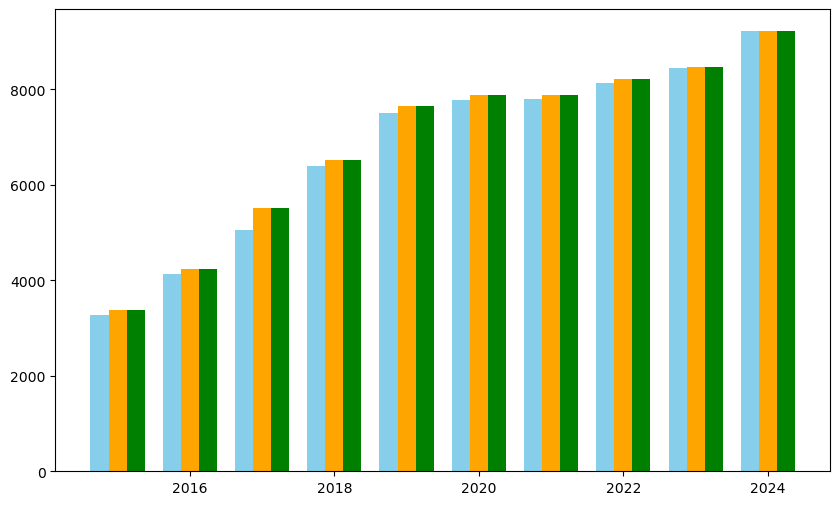

In [28]:
# Plot the data in a grouped bar chart
x = SMARD_data['Year']
width = 0.25  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, SMARD_data['Offshore [MW] - SMARD'], width, label='SMARD', color='skyblue')
bars2 = ax.bar(x, SMARD_data['MASTR'], width, label='MaStR', color='orange')
bars3 = ax.bar(x + width, SMARD_data['EC'], width, label='EC', color='green')

In [5]:
# Some data inspection because of nan values

# df_2['Kuestenentfernung'].isna().sum()

# df_2['Wassertiefe'].isna().sum()

# df_2[df_2['Kuestenentfernung'].isna()]

# All data entries without Wassertiefe and Kuestenentfernung are all in one windpark (not important for further analysis)

In [ ]:
dfs = ['df_2015', 'df_2016', 'df_2017', 'df_2018', 'df_2019', 'df_2020', 'df_2021', 'df_2022', 'df_2023', 'df_2024']
for year, df_year in zip(range(2015, 2025), [df_2015, df_2016, df_2017, df_2018, df_2019, df_2020, df_2021, df_2022, df_2023, df_2024]):
    # Transform to shapefile
    gdf = gpd.GeoDataFrame(df_year, geometry=gpd.points_from_xy(df_year['Laengengrad'], df_year['Breitengrad']))
    gdf.crs = 'EPSG:4326'
    # Create a grid
    grid = grid_func.create_ref_grid('wind_off_cap')# Extract lat/lon center coordinates from the xarray grid (assumed 1D)
    lat_vals = grid['lat'].values  # shape (N,)
    lon_vals = grid['lon'].values  # shape (M,)

    # Create 2D meshgrid of all (lat, lon) combinations
    lat_mesh, lon_mesh = np.meshgrid(lat_vals, lon_vals, indexing='ij')  # shape (N, M)

    # Flatten meshgrid into a (N*M, 2) array of grid point coordinates
    grid_points = np.column_stack((lat_mesh.ravel(), lon_mesh.ravel()))

    # Build KDTree for fast nearest neighbor search
    tree = cKDTree(grid_points)

    # Extract coordinates from GeoDataFrame into a (n_points, 2) array
    data_points = np.column_stack((gdf["Breitengrad"].values, gdf["Laengengrad"].values))

    # Query KDTree to find nearest grid point for each data point
    distances, flat_indices = tree.query(data_points)  # returns (distance, index)

    # Convert flat index to 2D grid indices (lat_idx, lon_idx)
    gdf["lat_idx"], gdf["lon_idx"] = np.unravel_index(flat_indices, lat_mesh.shape)  # shape (n_points,)

    grid_sums = gdf.groupby(["lat_idx", "lon_idx"])["Bruttoleistung"].sum()

    # Write the sums to the grid
    for (lat_idx, lon_idx), value in grid_sums.items():
        grid[lat_idx, lon_idx] = value

    # Show resulting grid
    # print(grid)

    # show overall sum
    print(gdf['Bruttoleistung'].sum())
    grid = grid.assign_attrs(gridtype='lonlat', crs='EPSG:4326')
    grid
    # Save grid as raster file
    # grid.to_netcdf(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_{year}.nc')
    
    # Create a grid
    grid_height = grid_func.create_ref_grid('wind_off_hub_height')
    # grid_height
    # Drop data without height values
    gdf_2 = gdf.dropna(subset=['Nabenhoehe'])
    grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"]))
    grid_mean_height_weighted

    # Write the sums to the grid
    for (lat_idx, lon_idx), value in grid_mean_height_weighted.items():
        grid_height[lat_idx, lon_idx] = value

    # Show resulting grid
    # print(grid_height)

    # Save grid as raster file
    # grid_height.to_netcdf(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_{year}.nc')

3381900.0
4237308.0
5522908.0
6513308.0
7655138.0
7874018.0
7874018.0
8216018.0
8473193.0


/tmp/ipykernel_299127/2293218600.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"]))
/tmp/ipykernel_299127/2293218600.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Na

9215093.0


/tmp/ipykernel_299127/2293218600.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"]))


In [38]:
grid_2015 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_2015.nc')
grid_2016 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_2016.nc')
grid_2017 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_2017.nc')
grid_2018 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_2018.nc')
grid_2019 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_2019.nc')
grid_2020 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_2020.nc')
grid_2021 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_2021.nc')
grid_2022 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_2022.nc')
grid_2023 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_2023.nc')
grid_2024 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_2024.nc')

In [40]:
grid_2015_sum = grid_2015['wind_off_cap'].sum() / 1000000
grid_2016_sum = grid_2016['wind_off_cap'].sum() / 1000000
grid_2017_sum = grid_2017['wind_off_cap'].sum() / 1000000
grid_2018_sum = grid_2018['wind_off_cap'].sum() / 1000000
grid_2019_sum = grid_2019['wind_off_cap'].sum() / 1000000
grid_2020_sum = grid_2020['wind_off_cap'].sum() / 1000000
grid_2021_sum = grid_2021['wind_off_cap'].sum() / 1000000
grid_2022_sum = grid_2022['wind_off_cap'].sum() / 1000000
grid_2023_sum = grid_2023['wind_off_cap'].sum() / 1000000
grid_2024_sum = grid_2024['wind_off_cap'].sum() / 1000000

In [42]:
lon_edges = grid_2024.lon.values
lat_edges = grid_2024.lat.values
# lat_edges = np.insert(lat_edges, 0, 46)


# Convert to MW
xxx1 = grid_2015['wind_off_cap'] / 1000000
xxx2 = grid_2016['wind_off_cap'] / 1000000
xxx3 = grid_2017['wind_off_cap'] / 1000000
xxx4 = grid_2018['wind_off_cap'] / 1000000
xxx5 = grid_2019['wind_off_cap'] / 1000000
xxx6 = grid_2020['wind_off_cap'] / 1000000
xxx7 = grid_2021['wind_off_cap'] / 1000000
xxx8 = grid_2022['wind_off_cap'] / 1000000
xxx9 = grid_2023['wind_off_cap'] / 1000000
xxx10 = grid_2024['wind_off_cap'] / 1000000

# Determine the common colorbar range
vmin = 0 # min(xxx1.min(), xxx2.min(), xxx3.min())
vmax = max(xxx1.max(), xxx2.max(), xxx3.max(), xxx4.max(), xxx5.max(), xxx6.max(), xxx7.max(), xxx8.max(), xxx9.max(), xxx10.max())


In [43]:
def setup_gridlines(ax, deg=2, alpha=0, ll=True):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    # make sure ticks line up with gridlines:
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=10)
    
def setup_gridlines_small(ax, deg = 2, alpha = 0.4, ll = True, bl = True, label_size = 16):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    # ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    # ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=18)

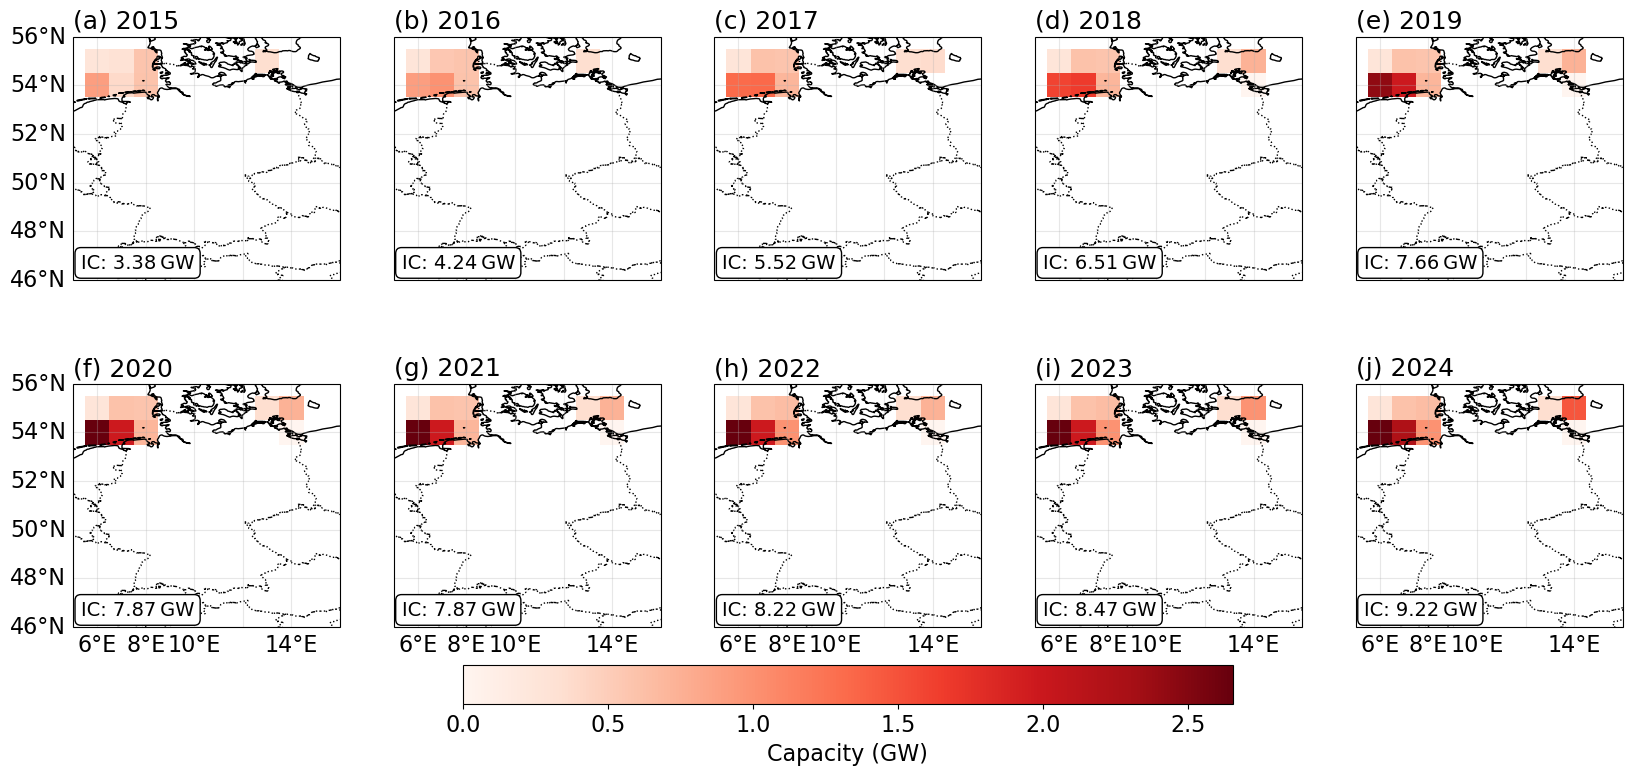

In [44]:
import matplotlib as mpl
import matplotlib.ticker as mticker
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

lon_min, lon_max = lon_edges.min(), lon_edges.max()
lat_min, lat_max = lat_edges.min(), lat_edges.max()

fig, axes = plt.subplots(
    2, 5, figsize=(20, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'hspace': 0.003} 
)

axes = axes.flatten()

# axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]
data = [xxx1, xxx2, xxx3, xxx4, xxx5, xxx6, xxx7, xxx8, xxx9, xxx10]
labels = ['(a) 2015', '(b) 2016', '(c) 2017', '(d) 2018', '(e) 2019', '(f) 2020', '(g) 2021', '(h) 2022', '(i) 2023', '(j) 2024']
capacities = [
    f"IC: {grid_2015_sum.values:.2f} GW",
    f"IC: {grid_2016_sum.values:.2f} GW",
    f"IC: {grid_2017_sum.values:.2f} GW",
    f"IC: {grid_2018_sum.values:.2f} GW",
    f"IC: {grid_2019_sum.values:.2f} GW",
    f"IC: {grid_2020_sum.values:.2f} GW",
    f"IC: {grid_2021_sum.values:.2f} GW",
    f"IC: {grid_2022_sum.values:.2f} GW",
    f"IC: {grid_2023_sum.values:.2f} GW",
    f"IC: {grid_2024_sum.values:.2f} GW",
]
label_sizes = {'title': 18, 'box': 14}

for ax, dat, lab, cap, ll, bl in zip(axes, data, labels, capacities, [True, False, False, False, False, True, False, False, False, False], [False, False, False, False, False, True, True, True, True, True]):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    im = ax.pcolormesh(
        lon_edges, lat_edges, dat,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=vmin, vmax=vmax
    )
    
    ax.set_extent([lon_min-1, lon_max+1.001, lat_min - 1.001, lat_max+1.001], crs=ccrs.PlateCarree())

    setup_gridlines_small(ax, deg=2, alpha=0.3, ll=ll, bl=bl)

    # Left‑aligned title
    ax.set_title(lab, loc='left', fontsize=label_sizes['title'])

    # Boxed capacity text in lower right (axes coords)
    ax.text(
        0.03, 0.03, cap,
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=label_sizes['box'],
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

# Single shared colorbar below all panels
cbar = fig.colorbar(
    im, ax=axes, orientation='horizontal',
    fraction=0.05,  # height of colorbar
    pad=0.05        # space between panels and colorbar
)
cbar.set_label('Capacity (GW)')
cbar.ax.tick_params()
# Explicit ticks from 0.0 to 4.0 every 0.5
# ticks = np.arange(0.0, 4.0 + 0.5, 0.5)   # array([0. , 0.5, 1. , ..., 4. ])
# cbar.set_ticks(ticks)

# Force one decimal place on tick labels
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# plt.tight_layout()
# save the plot
# plt.savefig('/home/onennecke/Code/Figures/Installed_capacity.png', dpi=600, bbox_inches='tight')
plt.show()

In [47]:
grid_hh_2015 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_2015.nc')
grid_hh_2016 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_2016.nc')
grid_hh_2017 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_2017.nc')
grid_hh_2018 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_2018.nc')
grid_hh_2019 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_2019.nc')
grid_hh_2020 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_2020.nc')
grid_hh_2021 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_2021.nc')
grid_hh_2022 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_2022.nc')
grid_hh_2023 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_2023.nc')
grid_hh_2024 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_2024.nc')

In [52]:
lon_edges = grid_2024.lon.values
lat_edges = grid_2024.lat.values
# lat_edges = np.insert(lat_edges, 0, 46)


# Convert to MW
xxx1 = grid_hh_2015['wind_off_hub_height']
xxx2 = grid_hh_2016['wind_off_hub_height']
xxx3 = grid_hh_2017['wind_off_hub_height']
xxx4 = grid_hh_2018['wind_off_hub_height']
xxx5 = grid_hh_2019['wind_off_hub_height']
xxx6 = grid_hh_2020['wind_off_hub_height']
xxx7 = grid_hh_2021['wind_off_hub_height']
xxx8 = grid_hh_2022['wind_off_hub_height']
xxx9 = grid_hh_2023['wind_off_hub_height']
xxx10 = grid_hh_2024['wind_off_hub_height']
# Determine the common colorbar range
vmin = 0 # min(xxx1.min(), xxx2.min(), xxx3.min())
vmax = max(xxx1.max(), xxx2.max(), xxx3.max(), xxx4.max(), xxx5.max(), xxx6.max(), xxx7.max(), xxx8.max(), xxx9.max(), xxx10.max())



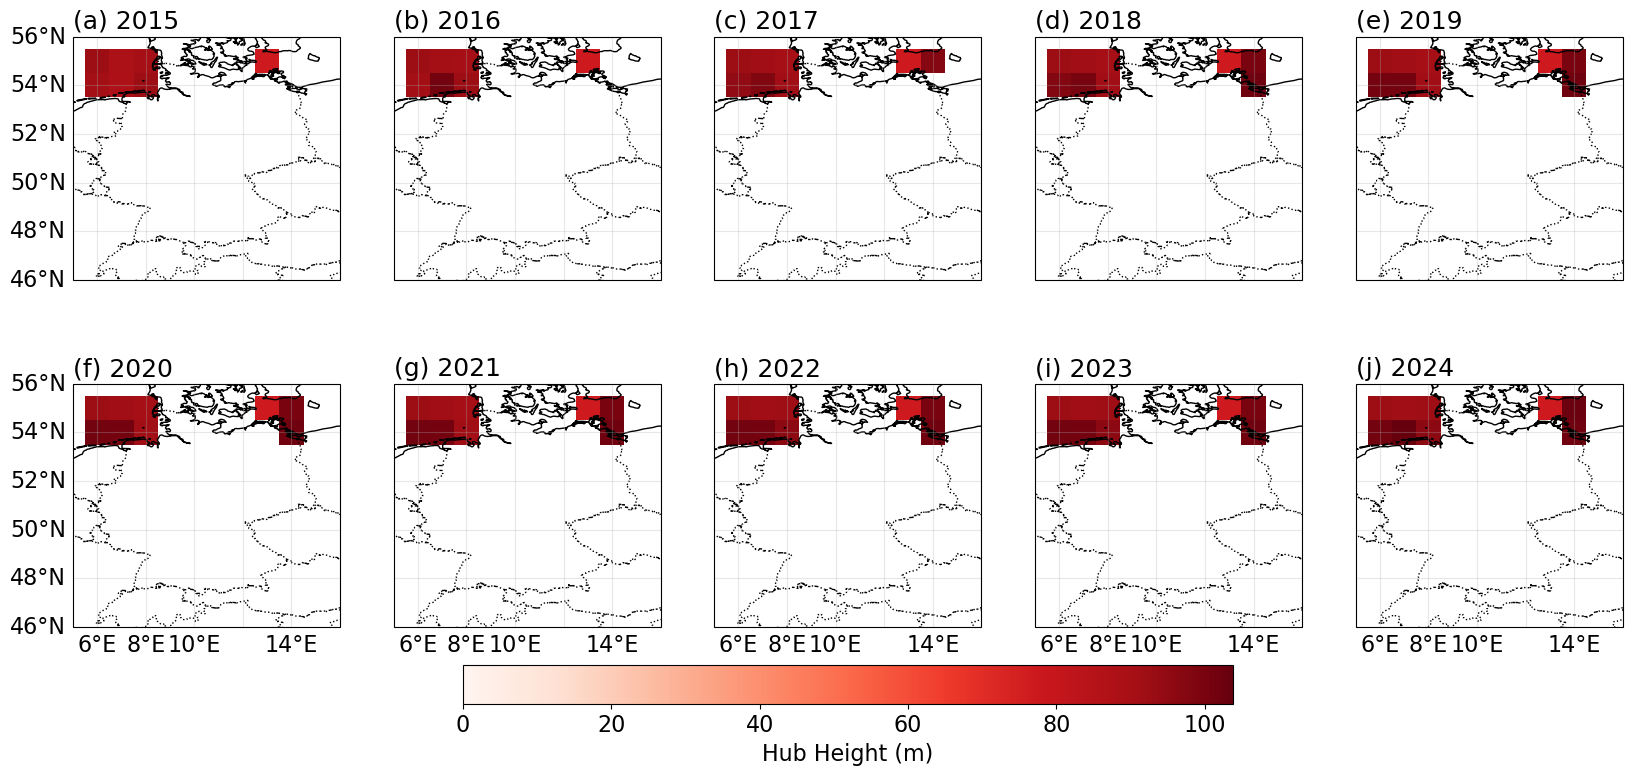

In [54]:
import matplotlib as mpl
import matplotlib.ticker as mticker
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

lon_min, lon_max = lon_edges.min(), lon_edges.max()
lat_min, lat_max = lat_edges.min(), lat_edges.max()

fig, axes = plt.subplots(
    2, 5, figsize=(20, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'hspace': 0.003} 
)

axes = axes.flatten()

# axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]
data = [xxx1, xxx2, xxx3, xxx4, xxx5, xxx6, xxx7, xxx8, xxx9, xxx10]
labels = ['(a) 2015', '(b) 2016', '(c) 2017', '(d) 2018', '(e) 2019', '(f) 2020', '(g) 2021', '(h) 2022', '(i) 2023', '(j) 2024']

label_sizes = {'title': 18, 'box': 14}

for ax, dat, lab, ll, bl in zip(axes, data, labels, [True, False, False, False, False, True, False, False, False, False], [False, False, False, False, False, True, True, True, True, True]):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    im = ax.pcolormesh(
        lon_edges, lat_edges, dat,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=vmin, vmax=vmax
    )
    
    ax.set_extent([lon_min-1, lon_max+1.001, lat_min - 1.001, lat_max+1.001], crs=ccrs.PlateCarree())

    setup_gridlines_small(ax, deg=2, alpha=0.3, ll=ll, bl=bl)

    # Left‑aligned title
    ax.set_title(lab, loc='left', fontsize=label_sizes['title'])



# Single shared colorbar below all panels
cbar = fig.colorbar(
    im, ax=axes, orientation='horizontal',
    fraction=0.05,  # height of colorbar
    pad=0.05        # space between panels and colorbar
)
cbar.set_label('Hub Height (m)')
cbar.ax.tick_params()
# Explicit ticks from 0.0 to 4.0 every 0.5
# ticks = np.arange(0.0, 4.0 + 0.5, 0.5)   # array([0. , 0.5, 1. , ..., 4. ])
# cbar.set_ticks(ticks)

# Force one decimal place on tick labels
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

# plt.tight_layout()
# save the plot
# plt.savefig('/home/onennecke/Code/Figures/Installed_capacity.png', dpi=600, bbox_inches='tight')
plt.show()
